In [1]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
housing = fetch_california_housing()
X = housing.data
y = housing.target

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 特征标准化（梯度下降收敛的关键）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 增加偏置项（截距 b），在特征矩阵前加一列 1
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

In [3]:
class MyLinearRegression:
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None 
    
    def fit(self, X, y):
        n_features = X.shape[1]
        # 随机初始化权重
        self.weights = np.random.randn(n_features) * 0.01
        
        for _ in range(self.n_iterations):
            y_pred = X.dot(self.weights)
            error = y_pred - y
            # 计算梯度并更新权重
            gradient = (1 / len(y)) * X.T.dot(error)
            self.weights -= self.learning_rate * gradient
            
    def predict(self, X):
        return X.dot(self.weights)

In [4]:
model = MyLinearRegression(learning_rate=0.1, n_iterations=2000)
model.fit(X_train_b, y_train)
y_pred = model.predict(X_test_b)

# 计算 MSE 和 R² 指标
mse = np.mean((y_test - y_pred)**2)
ss_res = np.sum((y_test - y_pred)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - (ss_res / ss_tot)

print(f"基础线性回归 MSE: {mse:.4f}")
print(f"基础线性回归 R²: {r2:.4f}")

基础线性回归 MSE: 0.5559
基础线性回归 R²: 0.5758


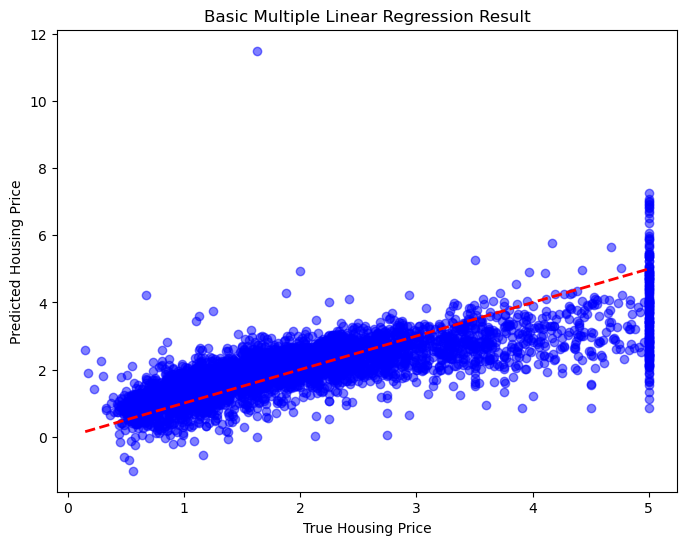

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) 
plt.xlabel("True Housing Price")  
plt.ylabel("Predicted Housing Price")  
plt.title("Basic Multiple Linear Regression Result")  
plt.show()